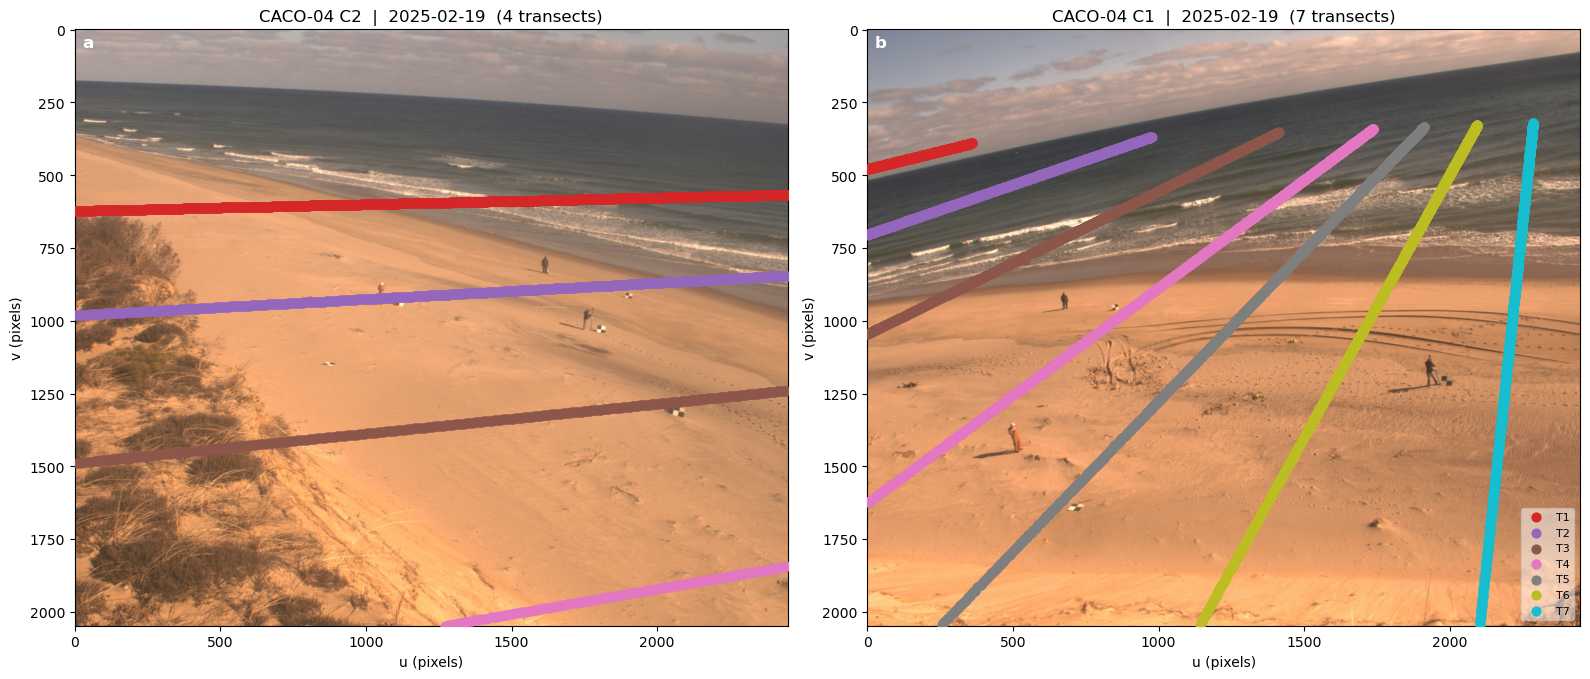

In [6]:
# csherwood@usgs.gov, 2026-06-10, generated with Claude Sonnet 4.6
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image

# ── Configuration ─────────────────────────────────────────────────────────────
PIX_DIR  = r"F:\crs\proj\marconi_imagery\pixel_locations"
IMG_DIR  = r"F:\crs\proj\2025-02-19_Marconi_extrinsic_cal"
C1_PIX   = PIX_DIR + r"\c1_timestack.pix"
C2_PIX   = PIX_DIR + r"\c2_timestack.pix"
C1_IMG   = IMG_DIR + r"\1739976900.Wed.Feb.19_14_55_00.GMT.2025.CACO-04.c1.snap.jpg"
C2_IMG   = IMG_DIR + r"\1739977140.Wed.Feb.19_14_59_00.GMT.2025.CACO-04.c2.snap.jpg"

N_TRANSECTS = 7       # total across both camerasA
N_C1        = 3       # transects in C1 (adjust if needed)
GAP_FACTOR  = 10.0     # jump must be this many times the median step to count as a break

# ── Load pixel coordinates ─────────────────────────────────────────────────────
c1_uv = np.loadtxt(C1_PIX)
c2_uv = np.loadtxt(C2_PIX)

# ── Detect transect breaks ─────────────────────────────────────────────────────
def get_transect_ids(uv, gap_factor=GAP_FACTOR):
    dists = np.linalg.norm(np.diff(uv, axis=0), axis=1)
    threshold = np.median(dists) * gap_factor
    breaks = np.where(dists > threshold)[0] + 1   # indices where new transect starts
    ids = np.zeros(len(uv), dtype=int)
    for seg_id, start in enumerate(breaks):
        ids[start:] = seg_id + 1
    return ids

N_C2_START = 3   # C2 begins at transect index 3 (i.e., the 4th transect)

c1_ids = get_transect_ids(c1_uv)
c2_ids = get_transect_ids(c2_uv) + N_C2_START

# ── Colormap: one color per transect, shared across both panels ────────────────
cmap = plt.colormaps.get_cmap('tab10')

# sample tab10 by integer index 0-9
def tab_color(i):
    return plt.colormaps['tab10'](i / 9)
# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, img_path, uv, ids, label in zip(
        axes,
        [C2_IMG, C1_IMG],
        [c2_uv,  c1_uv],
        [c2_ids, c1_ids],
        ['a',    'b']):

    img = np.array(Image.open(img_path))
    ax.imshow(img)

    cam = 'C1' if 'c1' in img_path else 'C2'
    cstart = 0 if cam=='C2' else 3

    for tid in np.unique(ids):
        mask = ids == tid
        ax.scatter(uv[mask, 0], uv[mask, 1],
                   color=tab_color(tid+cstart), s=40, zorder=5,
                   label=f'T{tid+1}')

    ax.set_title(f'CACO-04 {cam}  |  2025-02-19  ({len(np.unique(ids))} transects)')
    ax.set_xlabel('u (pixels)')
    ax.set_ylabel('v (pixels)')
    ax.text(0.01, 0.99, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='left', color='white')

# shared legend on the right panel
axes[1].legend(loc='lower right', fontsize=8, framealpha=0.5)

plt.tight_layout()A
plt.savefig('timestack_pixel_locations_overlay.png', dpi=150, bbox_inches='tight')
plt.show()